1.1 Chargement des données
- Votre première tâche consiste à importer les bibliothèques Python nécessaires
pour réaliser ce TD.
- Ensuite, chargez le fichier de données T1.csv dans un DataFrame Pandas nommé
df_wind.
➤ Quelle colonne devez-vous utiliser comme index ? Pourquoi ?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Correction du chargement pour éviter le blocage de l'affichage (Date/Time en datetime)
df_wind = pd.read_csv('../dataset/T1.csv', index_col='Date/Time', parse_dates=['Date/Time'], dayfirst=True)
df_wind.head()

,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
Date/Time,,,,
2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904
2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113
2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789
2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087
2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286


1.2 Exploration des données
Dans cette partie, vous allez explorer le jeu de données afin de comprendre sa structure
et son contenu.
- Quelle est la taille du DataFrame chargé ?

In [2]:
print("Taille du DataFrame:", df_wind.shape) # (50530, 4)
print("Nombre de lignes:", df_wind.shape[0], "| Nombre de colonnes:", df_wind.shape[1])

Taille du DataFrame: (50530, 4)
Nombre de lignes: 50530 | Nombre de colonnes: 4


- Affichez les 5 premières lignes et les 5 dernières lignes du DataFrame df_wind.
➤ Que pouvez-vous en déduire ? Pour quelle(s) année(s) l’éolienne a-t-elle
enregistré des données ?

In [3]:
print("5 premières lignes:")
display(df_wind.head())
print("5 dernières lignes:")
display(df_wind.tail())

# On peut en déduire que toutes les éoliennes enregistrés sont toutes de la même année, 2018

5 premières lignes:


,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
Date/Time,,,,
2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904
2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113
2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789
2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087
2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286


5 dernières lignes:


,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
Date/Time,,,,
2018-12-31 23:10:00,2963.980957,11.404030,3397.190793,80.502724
2018-12-31 23:20:00,1684.353027,7.332648,1173.055771,84.062599
2018-12-31 23:30:00,2201.106934,8.435358,1788.284755,84.742500
2018-12-31 23:40:00,2515.694092,9.421366,2418.382503,84.297913
2018-12-31 23:50:00,2820.466064,9.979332,2779.184096,82.274620


- Affichez le type de données de chaque colonne du dataset.

In [4]:
df_wind.dtypes

LV ActivePower (kW)              float64
Wind Speed (m/s)                 float64
Theoretical_Power_Curve (KWh)    float64
Wind Direction (°)               float64
dtype: object

- Vérifier la présence de valeurs manquantes.

In [5]:
print("Valeurs manquantes par colonne:")
df_wind.isnull().sum() # Il n'y a pas de valeur manquante

Valeurs manquantes par colonne:


LV ActivePower (kW)              0
Wind Speed (m/s)                 0
Theoretical_Power_Curve (KWh)    0
Wind Direction (°)               0
dtype: int64

- Extraire la colonne Wind Speed sous forme NumPy.

In [6]:
wind_speed_numpy = df_wind['Wind Speed (m/s)'].to_numpy()
wind_speed_numpy

array([5.31133604, 5.67216682, 5.2160368 , ..., 8.43535805, 9.42136574,
       9.97933197], shape=(50530,))

- Calculez la moyenne et l’écart-type de la variable vitesse du vent (Wind Speed).

In [7]:
mean_ws = df_wind['Wind Speed (m/s)'].mean()
std_ws = df_wind['Wind Speed (m/s)'].std()
print(f'Moyenne : {mean_ws} m/s') # environ 7,558
print(f'Ecart-type : {std_ws} m/s') # environ 4,227

Moyenne : 7.557952236083194 m/s
Ecart-type : 4.227166055611555 m/s


1.3 Manipulation des données
- Renommer les colonnes comme suit :
➤ Power au lieu de LV Active Power (kW)
➤ Wind speed au lieu de Wind Speed (m/s)
➤ Theoretical power au lieu de Theoretical Power (kWh)
➤ Wind direction au lieu de Wind Direction (°)

In [8]:
df_wind.rename(columns={
    'LV ActivePower (kW)': 'Power',
    'Wind Speed (m/s)': 'Wind speed',
    'Theoretical_Power_Curve (KWh)': 'Theoretical power',
    'Wind Direction (°)': 'Wind direction'
}, inplace=True)
df_wind.head()

,Power,Wind speed,Theoretical power,Wind direction
Date/Time,,,,
2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904
2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113
2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789
2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087
2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286


- Tracez l’évolution de la puissance produite (par intervalles de 10 minutes) en
fonction du temps.

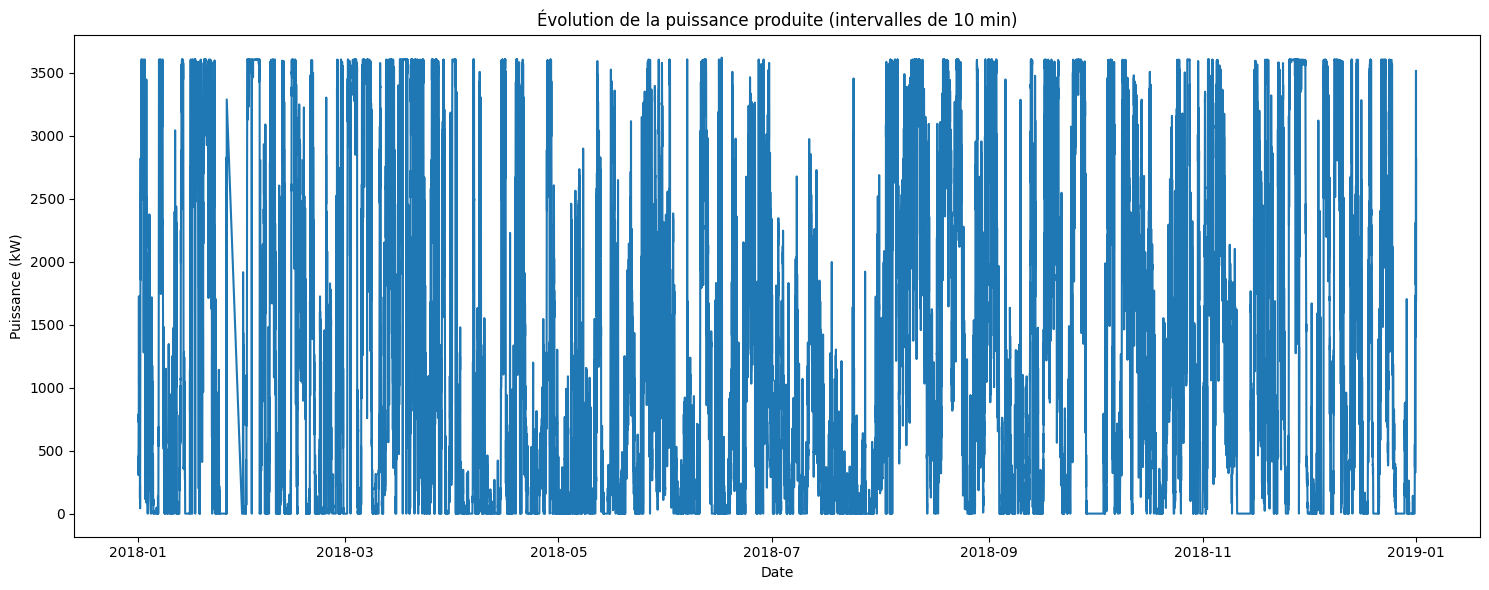

In [21]:
plt.figure(figsize=(15, 6))
plt.plot(df_wind.index, df_wind["Power"])
plt.xlabel("Date")
plt.ylabel("Puissance (kW)")
plt.title("Évolution de la puissance produite (intervalles de 10 min)")
plt.tight_layout()
plt.show()

- Créez une nouvelle colonne appelée loss, correspondant à la différence entre la
puissance théorique et la puissance réellement produite. Puis, tracez la perte
d’énergie en fonction du temps.
➤ Que pouvez-vous en conclure ?

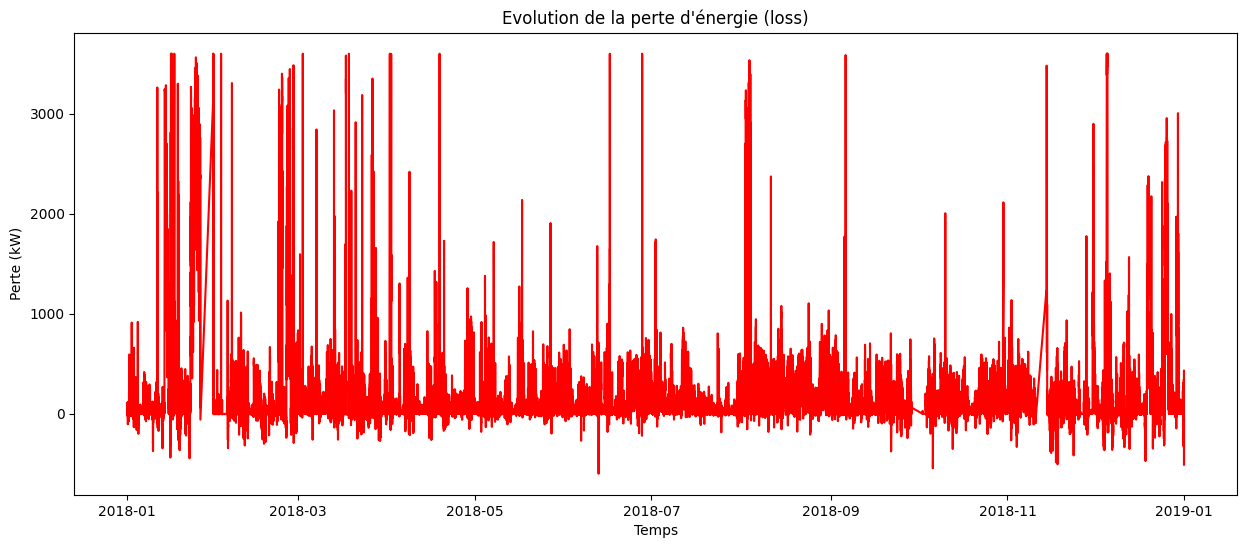

In [ ]:
df_wind['loss'] = df_wind['Theoretical power'] - df_wind['Power']

plt.figure(figsize=(15, 6))
plt.plot(df_wind['loss'], color='red')
plt.title('Evolution de la perte d\'énergie (loss)')
plt.xlabel('Temps')
plt.ylabel('Perte (kW)')
plt.show()
# L'analyse de la 'loss' permet d'identifier précisément les périodes d'indisponibilité de l'éolienne
# Les pics de perte correspondent à des phases de maintenance ou d'arrêt technique malgré un vent favorable. 

- Une éolienne commence généralement à produire de l’électricité pour une vitesse de
vent comprise entre 12 et 14 km/h (soit 3,3 à 3,8 m/s). Si la vitesse du vent est
supérieure à 3,3 m/s et que la puissance produite est nulle ou négative, on peut
supposer que l’éolienne est en maintenance.
➤ Identifiez les lignes correspondant à cette condition.
➤ Créez un nouveau DataFrame appelé df_wind_nm (sans maintenance), excluant
ces périodes

In [11]:
# Vitesse du vent > 3.3 & puissance <= 0
maintenance_mask = (df_wind['Wind speed'] > 3.3) & (df_wind['Power'] <= 0)
df_wind_nm = df_wind[~maintenance_mask].copy()
print(f'Lignes supprimées (maintenance) : {maintenance_mask.sum()}')
df_wind_nm.head()

Lignes supprimées (maintenance) : 2629


,Power,Wind speed,Theoretical power,Wind direction,loss
Date/Time,,,,,
2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904,36.281117
2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113,66.148316
2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789,84.523429
2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087,96.481664
2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286,111.052276


- Ensuite, tracez la perte d’énergie en fonction du temps pour le DataFrame
df_wind_nm.

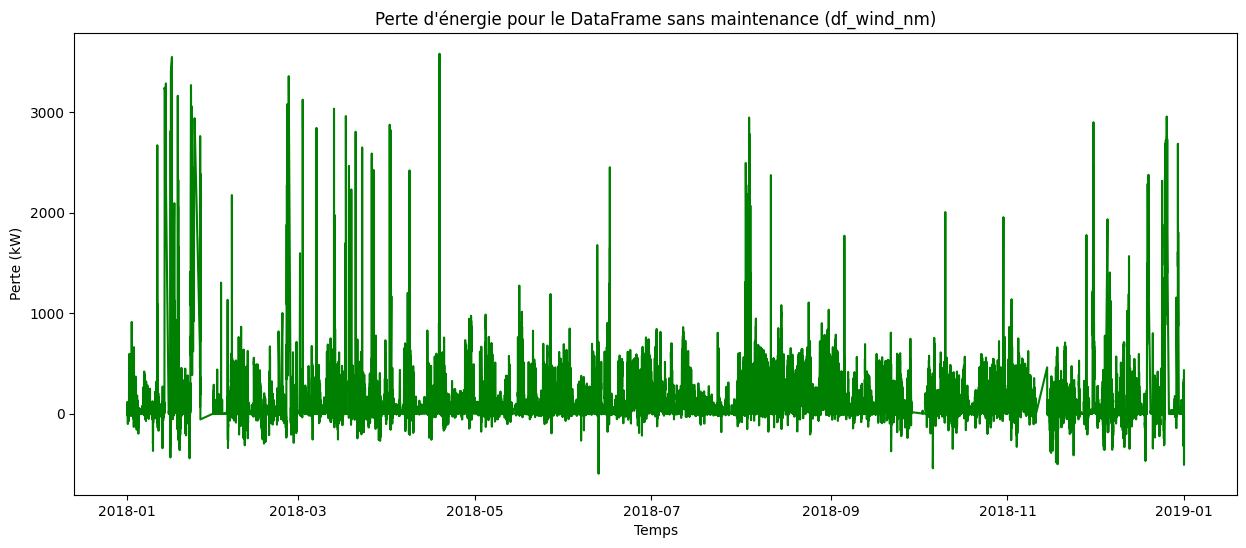

In [12]:
df_wind_nm['loss'] = df_wind_nm['Theoretical power'] - df_wind_nm['Power']

plt.figure(figsize=(15, 6))
plt.plot(df_wind_nm['loss'], color='green')
plt.title('Perte d\'énergie pour le DataFrame sans maintenance (df_wind_nm)')
plt.xlabel('Temps')
plt.ylabel('Perte (kW)')
plt.show()

- Tracez la différence de perte d’énergie entre les DataFrames avec maintenance
(df_wind) et sans maintenance (df_wind_nm).
➤ Quelle conclusion peut-on en tirer ?

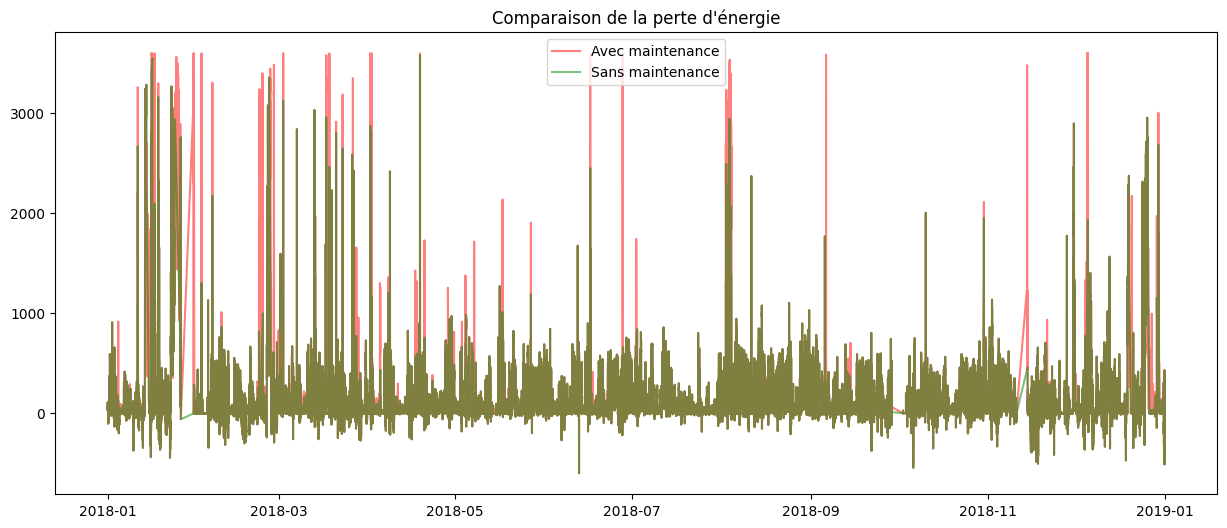

In [13]:
plt.figure(figsize=(15, 6))
plt.plot(df_wind['loss'], label='Avec maintenance', alpha=0.5, color='red')
plt.plot(df_wind_nm['loss'], label='Sans maintenance', alpha=0.5, color='green')
plt.title('Comparaison de la perte d\'énergie')
plt.legend()
plt.show()

# Conclusion: Le filtrage supprime les pics de perte aberrants liés à l'arrêt de l'éolienne par vent fort.

- Tracer la densité de probabilité (KDE) de la puissance et de la vitesse du vent du
DataFrame sans maintenance (df_wind_nm).

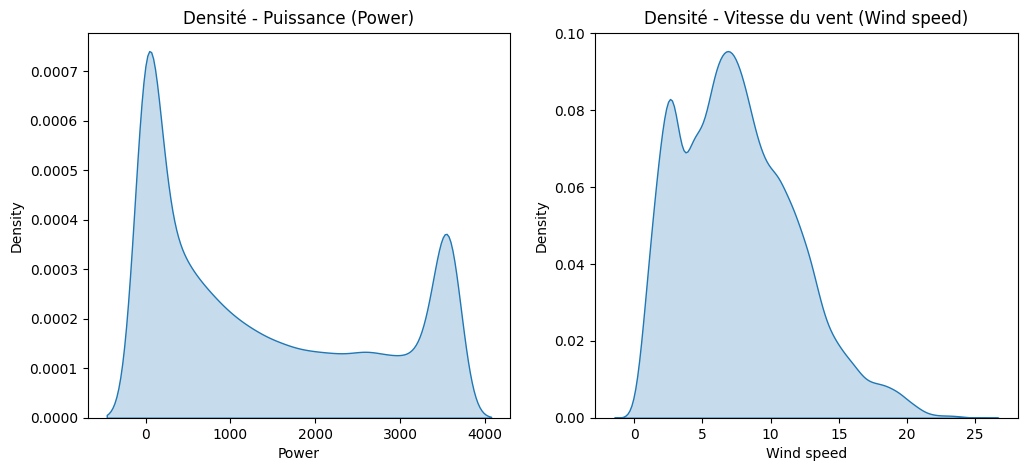

In [14]:
import seaborn as sns

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.kdeplot(df_wind_nm['Power'], fill=True)
plt.title('Densité - Puissance (Power)')

plt.subplot(1, 2, 2)
sns.kdeplot(df_wind_nm['Wind speed'], fill=True)
plt.title('Densité - Vitesse du vent (Wind speed)')
plt.show()

On souhaite maintenant créer les composantes x et y du vent à partir de la vitesse
et de la direction du vent.
➤ Les équations utilisées sont : (regarder le PDF)

où :
● Ws représente la vitesse du vent
● Wd représente la direction du vent
Ajoutez ces deux nouvelles colonnes (x et y) au dataset.


In [15]:
import numpy as np

ws = df_wind_nm['Wind speed']
wd_rad = df_wind_nm['Wind direction'] * np.pi / 180.0

df_wind_nm['x'] = ws * np.cos(wd_rad)
df_wind_nm['y'] = ws * np.sin(wd_rad)
df_wind_nm[['Wind speed', 'Wind direction', 'x', 'y']].head()

,Wind speed,Wind direction,x,y
Date/Time,,,,
2018-01-01 00:00:00,5.311336,259.994904,-0.922769,-5.230563
2018-01-01 00:10:00,5.672167,268.641113,-0.134514,-5.670572
2018-01-01 00:20:00,5.216037,272.564789,0.233413,-5.210812
2018-01-01 00:30:00,5.659674,271.258087,0.124264,-5.658310
2018-01-01 00:40:00,5.577941,265.674286,-0.420723,-5.562052


- Afin de réduire l’effet du bruit aléatoire, les données doivent être rééchantillonnées.


In [22]:
df_hourly = df_wind_nm.resample("h").mean()
df_daily = df_wind_nm.resample("d").mean()
df_weekly = df_wind_nm.resample("W").mean()
df_monthly = df_wind_nm.resample("ME").mean()

print("Horaire:", df_hourly.shape, "| Journalier:", df_daily.shape)
print("Hebdomadaire:", df_weekly.shape, "| Mensuel:", df_monthly.shape)

Horaire: (8760, 7) | Journalier: (365, 7)
Hebdomadaire: (53, 7) | Mensuel: (12, 7)


C:\Users\maxou\AppData\Local\Temp\ipykernel_18024\3848709036.py:2: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  df_daily = df_wind_nm.resample("d").mean()


➤ Créez des DataFrames horaire, journalier, hebdomadaire et mensuel à partir
du DataFrame sans maintenance, en utilisant la moyenne

➤ Utilisez la méthode resample() de Pandas, avec :
○ 'h' pour l’heure
○ 'd' pour le jour
○ 'W' pour la semaine
○ 'ME' pour le mois

In [23]:
df_hourly = df_wind_nm.resample('h').mean()
df_daily = df_wind_nm.resample('d').mean()
df_weekly = df_wind_nm.resample('W').mean()
df_monthly = df_wind_nm.resample('ME').mean()
print('DataFrames re-échantillonnés créés.')

DataFrames re-échantillonnés créés.


C:\Users\maxou\AppData\Local\Temp\ipykernel_18024\2650053161.py:2: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  df_daily = df_wind_nm.resample('d').mean()


➤ Tracez ensuite l’évolution de la puissance produite pour chaque fréquence sous
forme de sous-graphiques(sub-plots).







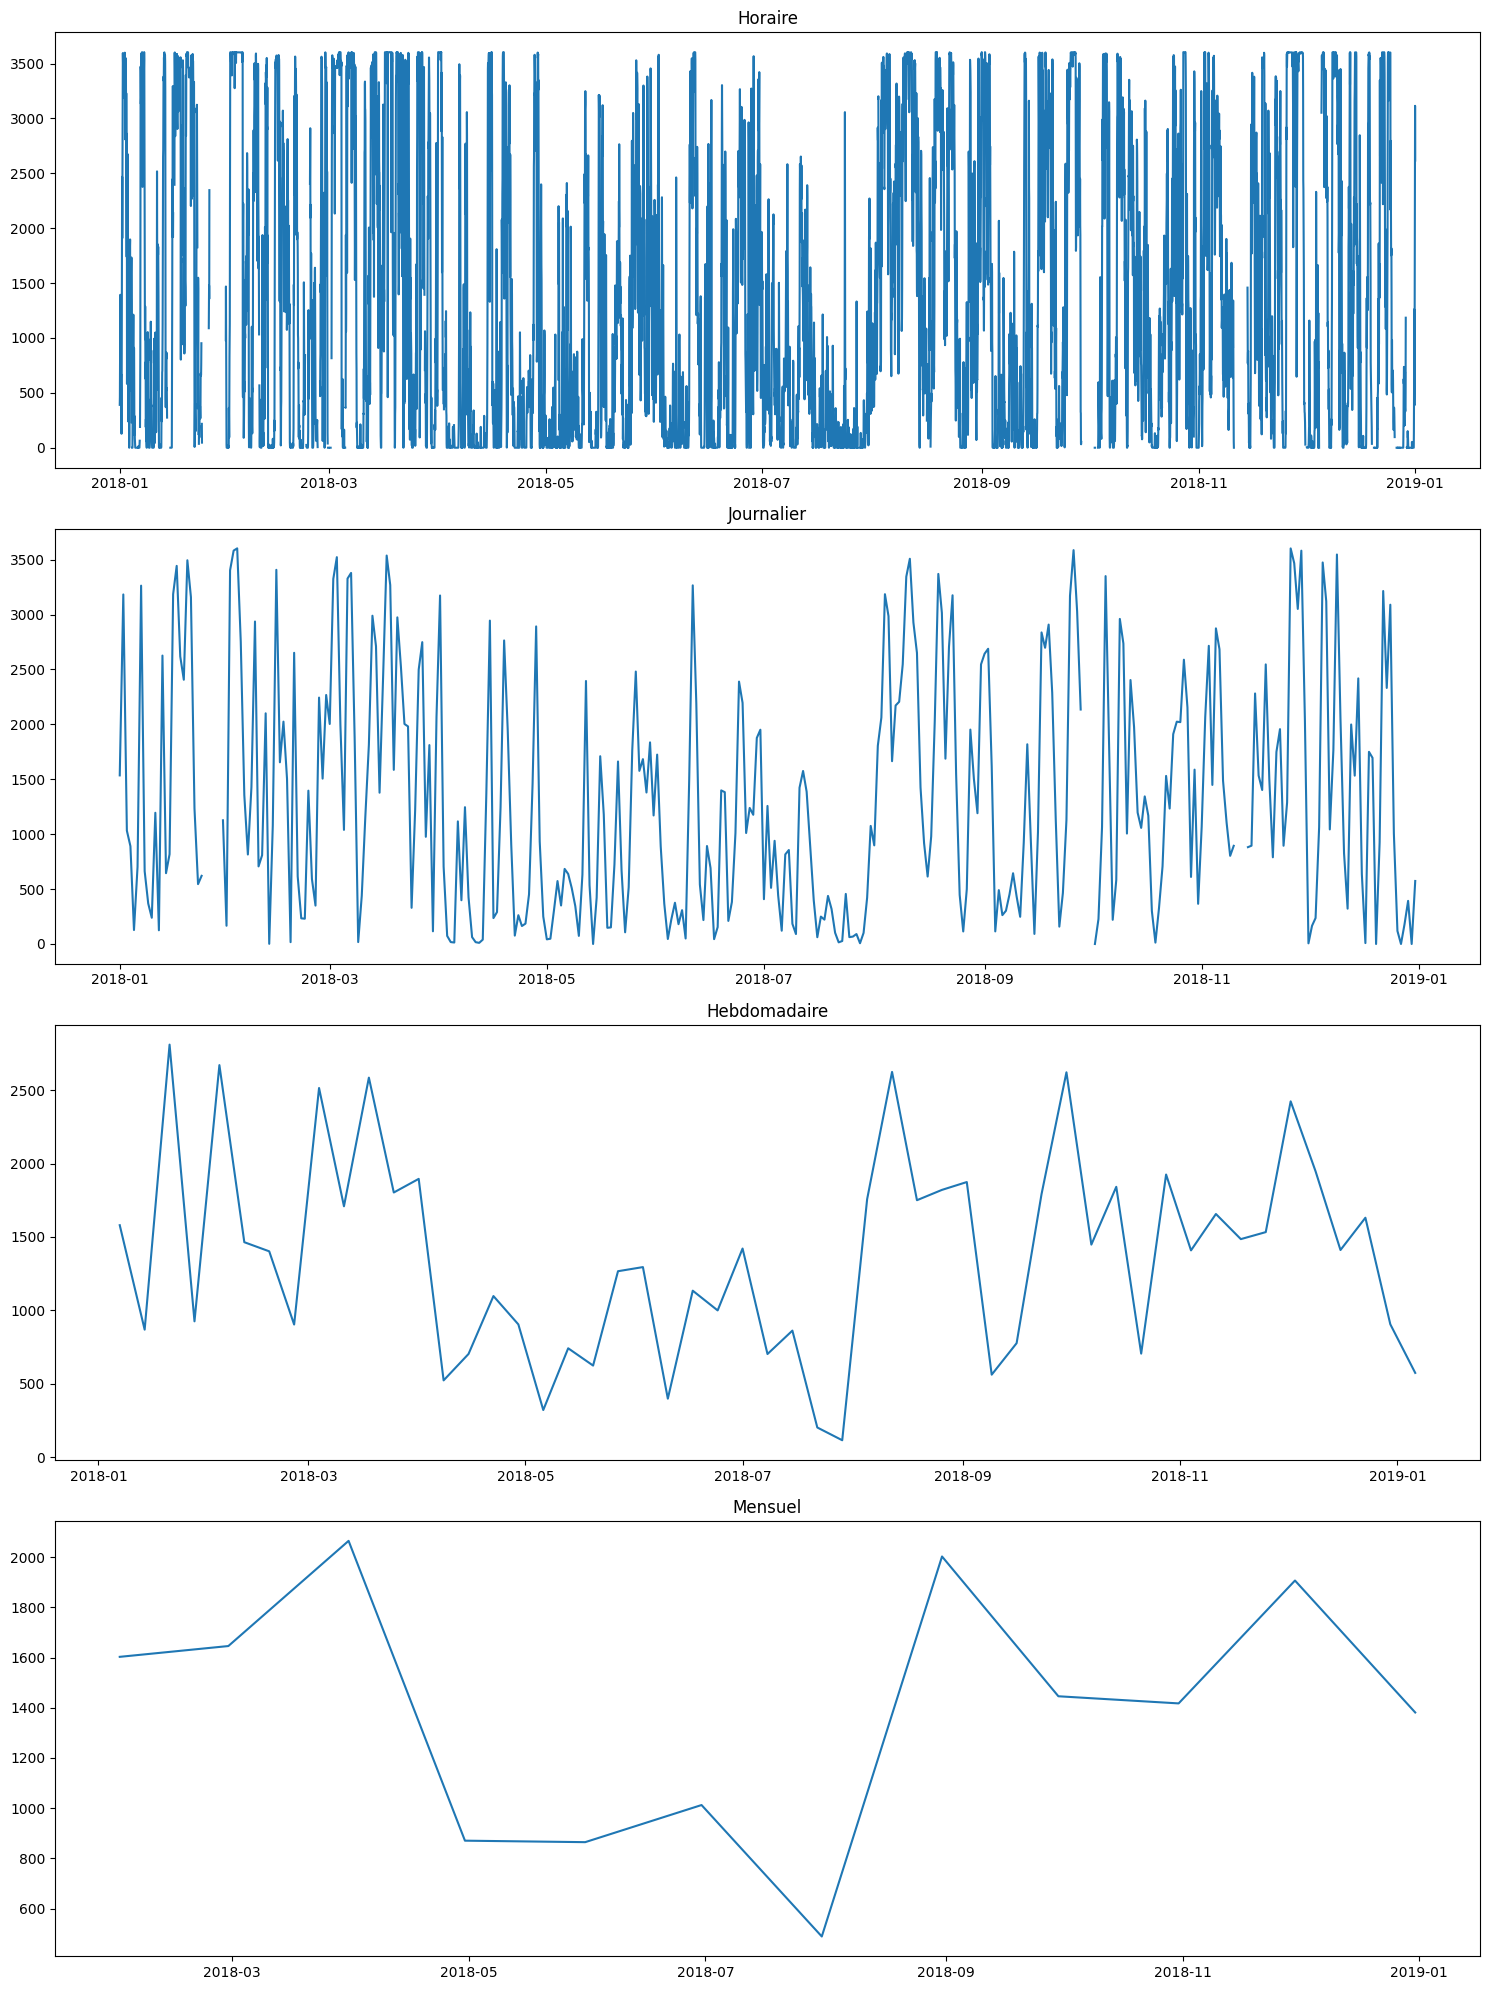

In [18]:
fig, axs = plt.subplots(4, 1, figsize=(15, 20))

axs[0].plot(df_hourly['Power'])
axs[0].set_title('Horaire')

axs[1].plot(df_daily['Power'])
axs[1].set_title('Journalier')

axs[2].plot(df_weekly['Power'])
axs[2].set_title('Hebdomadaire')

axs[3].plot(df_monthly['Power'])
axs[3].set_title('Mensuel')

plt.tight_layout()
plt.show()

➤ Vous pouvez également utiliser la fonction asfreq().


In [19]:
df_daily_asfreq = df_wind_nm['Power'].asfreq('d')
display(df_daily_asfreq.head())

C:\Users\maxou\AppData\Local\Temp\ipykernel_18024\64594341.py:1: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  df_daily_asfreq = df_wind_nm['Power'].asfreq('d')


Date/Time
2018-01-01     380.047791
2018-01-02    3377.649902
2018-01-03    2782.568115
2018-01-04    1121.166992
2018-01-05     845.205017
Freq: D, Name: Power, dtype: float64

➤ Quelle est la différence entre resample() et asfreq() ?


In [20]:
# resample() agrège les données (ex: moyenne sur la période),
# alors que asfreq() sélectionne la valeur à l'instant T (échantillonnage ponctuel).
# resample est plus robuste face au bruit.

- Remplacez toutes les valeurs NaN par des valeurs interpolées dans les DataFrames horaires journaliers, hebdomadaires et mensuels, en utilisant la fonction interpolate().


In [24]:
df_hourly = df_hourly.interpolate()
df_daily = df_daily.interpolate()
df_weekly = df_weekly.interpolate()
df_monthly = df_monthly.interpolate()
print("NaN après interpolation:", df_hourly.isna().sum().sum())

NaN après interpolation: 0


- Ajoutez et utilisez une fonction nommée direction afin de créer une nouvelle
colonne catégorielle appelée Direction. Cette fonction prend en entrée la vitesse
du vent.

In [25]:
def direction(wind_speed):
    if wind_speed < 5:
        return "faible"
    elif wind_speed < 10:
        return "modéré"
    else:
        return "fort"

- Ajoutez cette colonne aux DataFrames journalier, hebdomadaire et mensuel issus du DataFrame sans maintenance (df_wind_nm).

In [26]:
df_daily["Direction"] = df_daily["Wind speed"].apply(direction)
df_weekly["Direction"] = df_weekly["Wind speed"].apply(direction)
df_monthly["Direction"] = df_monthly["Wind speed"].apply(direction)
df_daily[["Wind speed", "Direction"]].head(10)

,Wind speed,Direction
Date/Time,,
2018-01-01,8.022975,modéré
2018-01-02,12.000548,fort
2018-01-03,6.689973,modéré
2018-01-04,6.338899,modéré
2018-01-05,3.106688,faible
2018-01-06,4.103764,faible
2018-01-07,12.193147,fort
2018-01-08,5.767732,modéré
2018-01-09,4.760865,faible


- Tracez l’évolution de la puissance produite du DataFrame horaire durant le mois de décembre. Puis, tracez un second graphique correspondant aux deux dernières semaines de décembre.

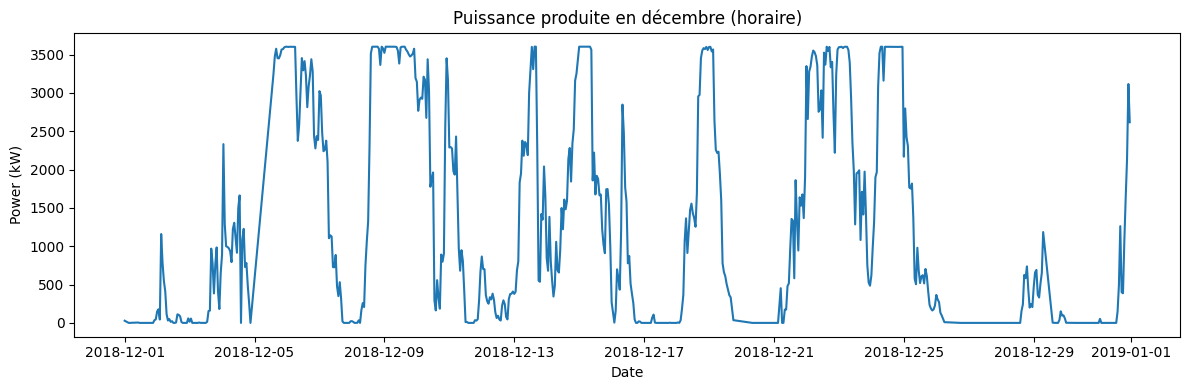

In [27]:
dec_hourly = df_hourly[df_hourly.index.month == 12]
plt.figure(figsize=(12, 4))
plt.plot(dec_hourly.index, dec_hourly["Power"])
plt.xlabel("Date")
plt.ylabel("Power (kW)")
plt.title("Puissance produite en décembre (horaire)")
plt.tight_layout()
plt.show()

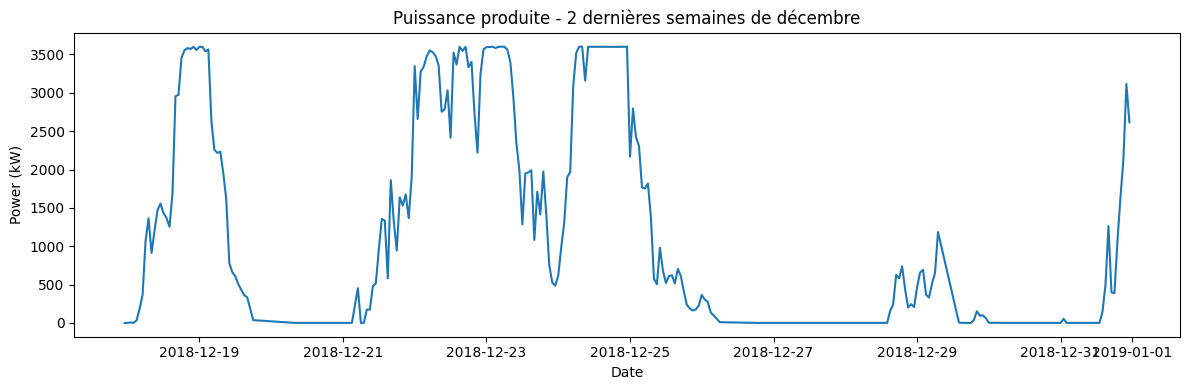

In [29]:
dec_hourly = df_hourly[(df_hourly.index.month == 12) & (df_hourly.index.year == 2018)]
last_two_weeks = dec_hourly[dec_hourly.index >= dec_hourly.index.max() - pd.Timedelta(days=14)]
plt.figure(figsize=(12, 4))
plt.plot(last_two_weeks.index, last_two_weeks["Power"])
plt.xlabel("Date")
plt.ylabel("Power (kW)")
plt.title("Puissance produite - 2 dernières semaines de décembre")
plt.tight_layout()
plt.show()

- Tracez la puissance moyenne produite à l’échelle hebdomadaire et mensuelle sur un même graphique.

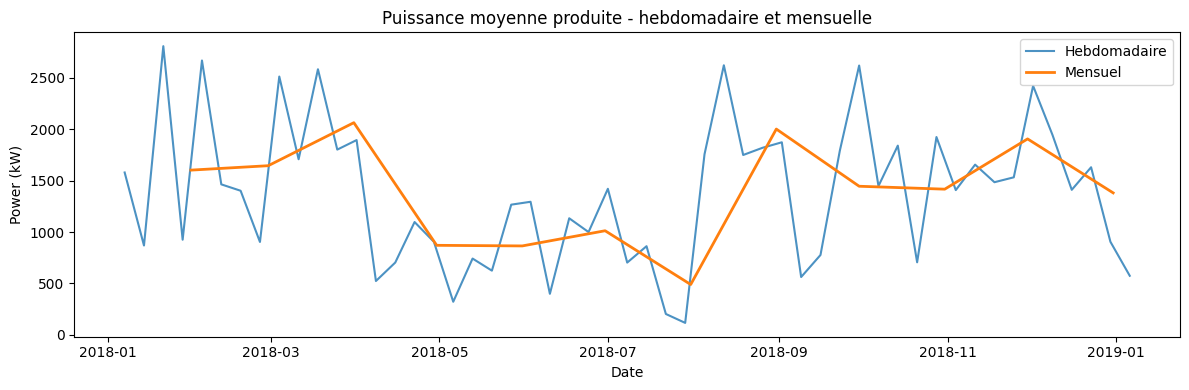

In [28]:
plt.figure(figsize=(12, 4))
plt.plot(df_weekly.index, df_weekly["Power"], label="Hebdomadaire", alpha=0.8)
plt.plot(df_monthly.index, df_monthly["Power"], label="Mensuel", linewidth=2)
plt.xlabel("Date")
plt.ylabel("Power (kW)")
plt.title("Puissance moyenne produite - hebdomadaire et mensuelle")
plt.legend()
plt.tight_layout()
plt.show()

- Appliquez le code fourni.
➤ Que pouvez-vous en conclure ?

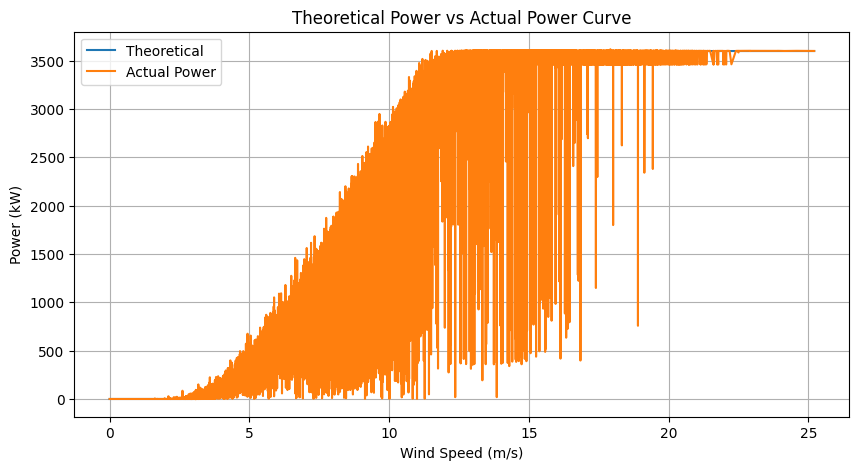

In [30]:
m_s_t_se = df_wind_nm.groupby('Wind speed')['Theoretical power'].mean()
m_s_p_se = df_wind_nm.groupby('Wind speed')['Power'].mean()
plt.figure(figsize=(10,5))
plt.plot(m_s_t_se, label='Theoretical')
plt.plot(m_s_p_se, label='Actual Power')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power (kW)')
plt.title('Theoretical Power vs Actual Power Curve')
plt.grid()
plt.legend()
plt.show()

# Une fois les périodes de maintenance filtrées, 
# la production réelle moyenne suit de très près la courbe de puissance théorique, 
# confirmant que l'éolienne fonctionne de manière optimale

- Tracer un pair-plot pour le DataFrame filtré. Quelles conclusions pouvez-vous en
tirer ?






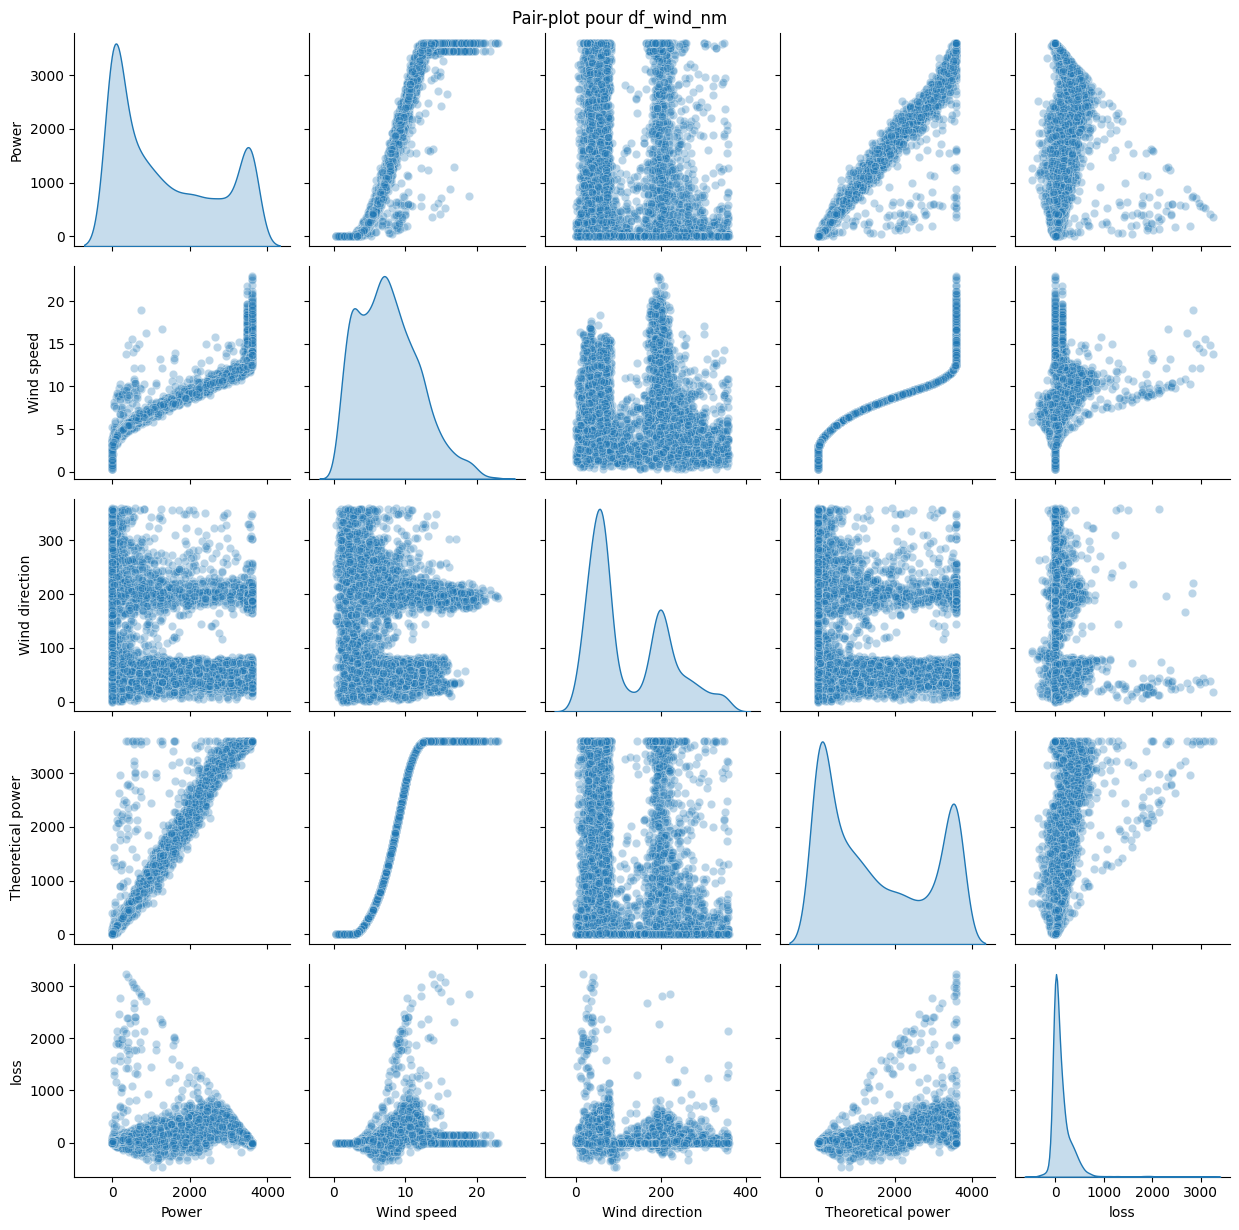

In [ ]:
cols_viz = ["Power", "Wind speed", "Wind direction", "Theoretical power", "loss"]
sample = df_wind_nm[cols_viz].dropna().sample(min(5000, len(df_wind_nm)), random_state=42)
sns.pairplot(sample, diag_kind="kde", plot_kws={"alpha": 0.3})
plt.suptitle("Pair-plot pour df_wind_nm")
plt.tight_layout()

# Ce graphique montre qu'une fois le "bruit" de la maintenance nettoyé, 
# l'éolienne fonctionne exactement comme prévu : 
# la production suit parfaitement la force du vent, 
# et la réalité correspond presque mot pour mot à la théorie.

- Tracer la carte de chaleur des corrélations. Que pouvez-vous en conclure ?


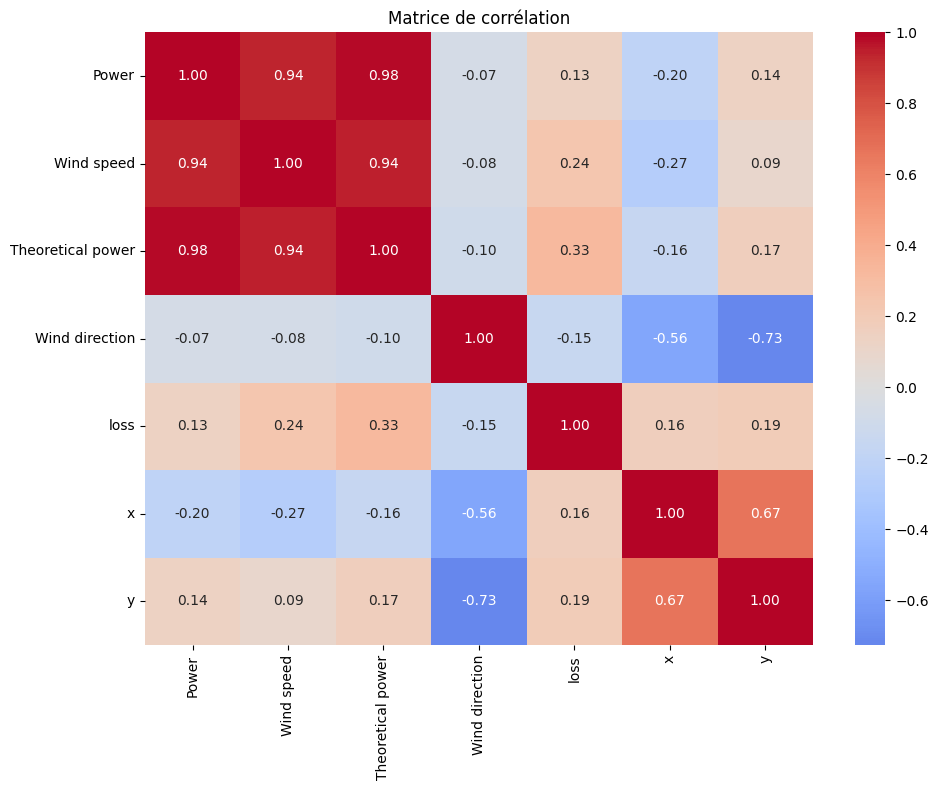

In [ ]:
numeriques = df_wind_nm.select_dtypes(include=[np.number])
corr = numeriques.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

# Ce tableau nous montre d'un coup d'œil ce qui fait tourner l'éolienne. 
# On voit très clairement que la puissance produite est presque totalement liée à la vitesse du vent : 
# plus ça souffle fort, plus on produit d'électricité, ce qui est logique. 

# Les autres facteurs, comme la direction du vent, 
# n'ont quasiment aucune influence directe sur la quantité d'énergie créée.

★ Quelles variables ont une corrélation plus forte avec la variable ‘Power’ ? Pouvez-vous les lister ?

In [38]:
# Seuil de corrélation (on considère que > 0.7 est une corrélation forte)
threshold = 0.7
power_corr = corr['Power'].abs()
no_corr_vars = power_corr[power_corr > threshold].index.tolist()

print(f"Variables ayant une corrélation forte avec 'Power' (valeur absolue > {threshold}) :")
for var in no_corr_vars:
    val = corr.loc[var, 'Power']
    print(f"- {var} : {val:.2f}")

Variables ayant une corrélation forte avec 'Power' (valeur absolue > 0.7) :
- Power : 1.00
- Wind speed : 0.94
- Theoretical power : 0.98


★ Quelles variables n’ont pas de corrélation avec ‘Power’ ? Pouvez-vous les lister ?

In [39]:
# Seuil de corrélation (on considère que < 0.3 est une corrélation faible)
threshold = 0.3
power_corr = corr['Power'].abs()
no_corr_vars = power_corr[power_corr < threshold].index.tolist()

print(f"Variables ayant une corrélation faible avec 'Power' (valeur absolue < {threshold}) :")
for var in no_corr_vars:
    val = corr.loc[var, 'Power']
    print(f"- {var} : {val:.2f}")

Variables ayant une corrélation faible avec 'Power' (valeur absolue < 0.3) :
- Wind direction : -0.07
- loss : 0.13
- x : -0.20
- y : 0.14


★ Pourrions-nous obtenir les mêmes résultats si d’autres méthodes de corrélation telles que le « coefficient de corrélation de Kendall Tau » ou la « corrélation par rang de Spearman » étaient utilisées

In [ ]:
corr_pearson = numeriques.corr(method='pearson')['Power']
corr_spearman = numeriques.corr(method='spearman')['Power']
corr_kendall = numeriques.corr(method='kendall')['Power']

df_corr_comp = pd.DataFrame({
    'Pearson': corr_pearson,
    'Spearman': corr_spearman,
    'Kendall': corr_kendall
})

print("Comparaison des méthodes de corrélation pour 'Power' :")
display(df_corr_comp)

### Comparaison des méthodes

Les méthodes de Spearman et Kendall confirment la forte corrélation entre la vitesse du vent et la puissance, tout en étant moins sensibles aux valeurs extrêmes que Pearson. On constate que la hiérarchie des corrélations reste la même : la vitesse du vent est le moteur principal.

- Tracer la perte d’énergie en fonction de la direction du vent. Que pouvez-vous en
conclure ?

In [ ]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x=df_wind_nm['Wind direction'], y=df_wind_nm['loss'], alpha=0.5, color='orange')
plt.title("Perte d'énergie en fonction de la direction du vent")
plt.xlabel("Direction du vent (°)")
plt.ylabel("Perte (Loss)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Conclusion sur les pertes

Le graphique montre que les pertes d'énergie sont réparties sur toutes les directions du vent. Il n'y a pas une direction spécifique qui semble causer systématiquement plus de pertes, ce qui suggère que l'implantation des éoliennes est bien optimisée ou que l'environnement est dégagé.

- Créer un nuage de points 3D avec les variables (x, y, z) : où ‘wind speed’ (vitesse du
vent), ‘wind direction’ (direction du vent) et ‘Power’ (puissance) représentent
respectivement les axes x, y et z. Que pouvez-vous en conclure ?

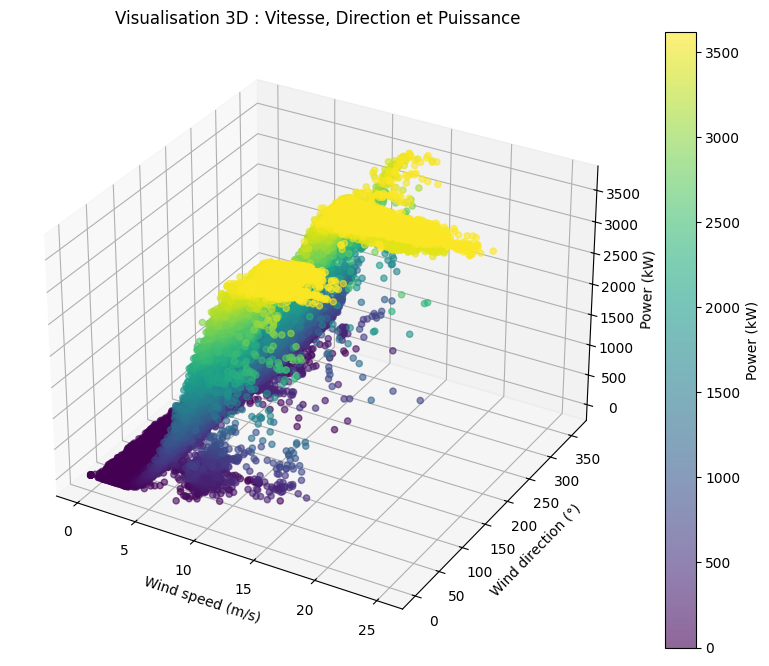

In [40]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

x = df_wind_nm['Wind speed']
y = df_wind_nm['Wind direction']
z = df_wind_nm['Power']

scatter = ax.scatter(x, y, z, c=z, cmap='viridis', marker='o', alpha=0.6)
plt.colorbar(scatter, ax=ax, label='Power (kW)')

ax.set_xlabel('Wind speed (m/s)')
ax.set_ylabel('Wind direction (°)')
ax.set_zlabel('Power (kW)')
plt.title("Visualisation 3D : Vitesse, Direction et Puissance")
plt.show()

### Conclusion sur la visualisation 3D

Cette visualisation 3D illustre clairement que la puissance grimpe avec la vitesse du vent (axe X), et ce, quelle que soit la direction (axe Y). La forme du nuage de points suit la courbe de puissance caractéristique de l'éolienne.